In [1]:
import dask
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
def calculate_taf_diagnostics(
    zarr_store,
    threshold_m=100.0,
    ocean_area_m2=3.618e14,
    show_progress=True,
):
    """
    Calculate a marine ice-sheet vulnerability diagnostic from BedMachine Antarctica.

    Parameters
    ----------
    zarr_store : str, pathlib.Path, MutableMapping, or xr.Dataset
        Path/URL/store for the Zarr dataset, or an already opened xarray Dataset.
    threshold_m : float
        Thickness-above-flotation threshold used to define "near flotation".
        Example: 100 m means grounded marine ice within 100 m of flotation.
    ocean_area_m2 : float
        Ocean area used for a simple sea-level-equivalent conversion.
    show_progress : bool
        Show a Dask progress bar while computing summary metrics.

    Returns
    -------
    calc : dict
        Dictionary containing:
          - "summary": computed scalar metrics
          - "fields": lazy xarray fields used by the plotting function
          - "parameters": densities, threshold, and grid-cell area
    """

    def _open(z):
        if isinstance(z, xr.Dataset):
            return z
        try:
            return xr.open_zarr(z, consolidated=True, chunks={})
        except Exception:
            return xr.open_zarr(z, consolidated=False, chunks={})

    def _attr_float(ds, names, default):
        for name in names:
            if name in ds.attrs:
                try:
                    return float(ds.attrs[name])
                except Exception:
                    pass
        return float(default)

    ds = _open(zarr_store)

    required = ["mask", "bed", "thickness"]
    missing = [name for name in required if name not in ds]
    if missing:
        raise ValueError(f"Dataset is missing required variables: {missing}")

    rho_i = _attr_float(
        ds,
        ["ice_density (kg m-3)", "ice_density", "rho_ice"],
        default=917.0,
    )
    rho_w = _attr_float(
        ds,
        ["sea_water_density (kg m-3)", "sea_water_density", "rho_water"],
        default=1027.0,
    )

    x = np.asarray(ds["x"].values)
    y = np.asarray(ds["y"].values)

    dx = float(np.nanmedian(np.abs(np.diff(x))))
    dy = float(np.nanmedian(np.abs(np.diff(y))))
    cell_area_m2 = dx * dy

    mask = ds["mask"]
    bed = ds["bed"]
    thickness = ds["thickness"]

    # BedMachine mask convention:
    # 2 = grounded ice.
    grounded = mask == 2

    # Marine-grounded ice is grounded ice sitting on bed below sea level.
    marine_grounded = (
        grounded
        & (bed < 0)
        & np.isfinite(bed)
        & np.isfinite(thickness)
    )

    # Hydrostatic flotation thickness.
    #
    # For bed below sea level:
    #     H_float = -(rho_w / rho_i) * bed
    #
    # For bed above sea level, flotation thickness is set to zero for this diagnostic.
    flotation_thickness = xr.where(
        bed < 0,
        -(rho_w / rho_i) * bed,
        0.0,
    )

    # Thickness above flotation.
    #
    # Positive TAF means the ice is thicker than needed to float.
    # Values near zero identify grounded marine ice close to flotation.
    taf = thickness - flotation_thickness

    taf_marine = taf.where(marine_grounded)
    taf_marine_positive = taf_marine.clip(min=0)

    near_flotation = marine_grounded & (taf >= 0) & (taf <= threshold_m)

    # For bed >= 0, treat all grounded ice thickness as above flotation.
    # This gives a broad total grounded volume-above-flotation diagnostic.
    taf_all_grounded_positive = xr.where(
        grounded,
        xr.where(bed < 0, taf.clip(min=0), thickness.clip(min=0)),
        np.nan,
    )

    metrics = xr.Dataset(
        {
            "grounded_ice_area_km2": (
                grounded.sum() * cell_area_m2 / 1e6
            ),
            "marine_grounded_ice_area_km2": (
                marine_grounded.sum() * cell_area_m2 / 1e6
            ),
            "near_flotation_area_km2": (
                near_flotation.sum() * cell_area_m2 / 1e6
            ),
            "mean_marine_grounded_taf_m": (
                taf_marine.mean(skipna=True)
            ),
            "min_marine_grounded_taf_m": (
                taf_marine.min(skipna=True)
            ),
            "grounded_ice_volume_km3": (
                thickness.where(grounded).sum(skipna=True) * cell_area_m2 / 1e9
            ),
            "marine_grounded_vaf_km3": (
                taf_marine_positive.sum(skipna=True) * cell_area_m2 / 1e9
            ),
            "total_grounded_vaf_km3": (
                taf_all_grounded_positive.sum(skipna=True) * cell_area_m2 / 1e9
            ),
        }
    )

    # Simple sea-level-equivalent conversion.
    # This is a diagnostic, not a full projection.
    metrics["marine_grounded_vaf_sle_mm"] = (
        metrics["marine_grounded_vaf_km3"]
        * 1e9
        * (rho_i / rho_w)
        / ocean_area_m2
        * 1000.0
    )

    metrics["total_grounded_vaf_sle_mm"] = (
        metrics["total_grounded_vaf_km3"]
        * 1e9
        * (rho_i / rho_w)
        / ocean_area_m2
        * 1000.0
    )

    # Optional uncertainty-flavoured diagnostic.
    # This is not a full uncertainty propagation, but it is useful for flagging
    # places where the TAF signal is comparable to mapped bed uncertainty.
    if "errbed" in ds:
        sigma_taf_from_bed = (rho_w / rho_i) * ds["errbed"]

        near_flotation_within_bed_error = (
            near_flotation
            & (taf <= sigma_taf_from_bed)
        )

        metrics["near_flotation_area_within_1sigma_bed_error_km2"] = (
            near_flotation_within_bed_error.sum() * cell_area_m2 / 1e6
        )

    if show_progress:
        with ProgressBar():
            metrics_computed = metrics.compute()
    else:
        metrics_computed = metrics.compute()

    summary = {
        name: float(metrics_computed[name].values.item())
        for name in metrics_computed.data_vars
    }

    return {
        "summary": summary,
        "fields": {
            # These remain lazy Dask-backed xarray objects.
            # The plotting function will coarsen and compute only what it needs.
            "taf_marine": taf_marine,
            "bed_grounded": bed.where(grounded),
            "marine_grounded": marine_grounded,
            "near_flotation": near_flotation,
        },
        "parameters": {
            "threshold_m": float(threshold_m),
            "rho_i_kg_m3": float(rho_i),
            "rho_w_kg_m3": float(rho_w),
            "cell_area_m2": float(cell_area_m2),
            "dx_m": float(dx),
            "dy_m": float(dy),
            "ocean_area_m2": float(ocean_area_m2),
        },
    }

In [6]:

def plot_taf_map(
    zarr_store,
    calc,
    plot_vmax_m=500.0,
    max_plot_pixels=1600,
    figsize=(9.5, 8.5),
    show_progress=True,
    save_path=None,
):
    """
    Create a map of grounded marine ice thickness above flotation.

    Parameters
    ----------
    zarr_store : str, pathlib.Path, MutableMapping, or xr.Dataset
        Same Zarr store used in calculate_taf_diagnostics.
        It is included so this function can be run cleanly in a separate notebook cell.
    calc : dict
        Output from calculate_taf_diagnostics.
    plot_vmax_m : float
        Upper color limit for the TAF map. Values above this are clipped.
    max_plot_pixels : int
        Maximum number of pixels along x or y after coarsening for plotting.
        Increase for sharper plots; decrease for faster plotting.
    figsize : tuple
        Matplotlib figure size.
    show_progress : bool
        Show a Dask progress bar while preparing the plot.
    save_path : str, pathlib.Path, or None
        Optional path for saving the figure.

    Returns
    -------
    fig, ax
        Matplotlib figure and axes.
    """

    def _open(z):
        if isinstance(z, xr.Dataset):
            return z
        try:
            return xr.open_zarr(z, consolidated=True, chunks={})
        except Exception:
            return xr.open_zarr(z, consolidated=False, chunks={})

    def _coarsen_for_plot(da_in, max_pixels):
        ny = da_in.sizes["y"]
        nx = da_in.sizes["x"]

        factor = max(1, int(np.ceil(max(nx, ny) / max_pixels)))

        if factor == 1:
            return da_in

        return da_in.coarsen(
            x=factor,
            y=factor,
            boundary="trim",
        ).mean()

    # Re-open mainly for validation and notebook robustness.
    ds = _open(zarr_store)

    if "x" not in ds.coords or "y" not in ds.coords:
        raise ValueError("Dataset must have x and y coordinates.")

    if calc is None or "fields" not in calc:
        raise ValueError(
            "Pass the output of calculate_taf_diagnostics as the calc argument."
        )

    taf_marine = calc["fields"]["taf_marine"]
    bed_grounded = calc["fields"]["bed_grounded"]

    threshold_m = calc.get("parameters", {}).get("threshold_m", 100.0)
    near_area_km2 = calc.get("summary", {}).get("near_flotation_area_km2", np.nan)

    # Clip before plotting so the color scale emphasizes ice close to flotation.
    taf_plot = taf_marine.clip(min=0, max=plot_vmax_m)

    # Coarsen so matplotlib is not asked to render the full 500 m grid.
    taf_plot = _coarsen_for_plot(taf_plot, max_plot_pixels)
    bed_plot = _coarsen_for_plot(bed_grounded, max_plot_pixels)

    if show_progress:
        with ProgressBar():
            taf_plot_c, bed_plot_c = dask.compute(taf_plot, bed_plot)
    else:
        taf_plot_c, bed_plot_c = dask.compute(taf_plot, bed_plot)

    x_km = taf_plot_c["x"].values / 1000.0
    y_km = taf_plot_c["y"].values / 1000.0

    origin = "upper" if y_km[0] > y_km[-1] else "lower"

    extent = [
        float(np.nanmin(x_km)),
        float(np.nanmax(x_km)),
        float(np.nanmin(y_km)),
        float(np.nanmax(y_km)),
    ]

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True,
    )

    im = ax.imshow(
        taf_plot_c.values,
        extent=extent,
        origin=origin,
        vmin=0,
        vmax=plot_vmax_m,
        cmap="viridis_r",
        interpolation="nearest",
    )

    cbar = fig.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label(
        f"Grounded marine thickness above flotation, clipped at {plot_vmax_m:.0f} m"
    )

    # Black contour: approximate bed = 0 m line over grounded ice.
    try:
        ax.contour(
            x_km,
            y_km,
            bed_plot_c.values,
            levels=[0],
            colors="black",
            linewidths=0.5,
        )
    except Exception:
        pass

    # White contour: chosen near-flotation threshold.
    try:
        ax.contour(
            x_km,
            y_km,
            taf_plot_c.values,
            levels=[threshold_m],
            colors="white",
            linewidths=0.9,
        )
    except Exception:
        pass

    ax.set_aspect("equal")
    ax.set_xlabel("EPSG:3031 x coordinate (km)")
    ax.set_ylabel("EPSG:3031 y coordinate (km)")

    ax.set_title(
        "Antarctic grounded marine ice near flotation\n"
        f"white contour: TAF = {threshold_m:.0f} m; "
        f"area below threshold = {near_area_km2:,.0f} km$^2$"
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=220,
            bbox_inches="tight",
        )

    return fig, ax

In [7]:

zarr_store = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAntarctica_19700101-20191001_V04.1.zarr/"

In [5]:
calc = calculate_taf_diagnostics(
    zarr_store,
    threshold_m=100,
)

calc["summary"]

[########################################] | 100% Completed | 79.40 s


{'grounded_ice_area_km2': 11999247.0,
 'marine_grounded_ice_area_km2': 5570879.75,
 'near_flotation_area_km2': 207717.75,
 'mean_marine_grounded_taf_m': 1684.9722900390625,
 'min_marine_grounded_taf_m': -47.541107177734375,
 'grounded_ice_volume_km3': 25482658.0,
 'marine_grounded_vaf_km3': 9386794.0,
 'total_grounded_vaf_km3': 22338140.0,
 'marine_grounded_vaf_sle_mm': 23165.81640625,
 'total_grounded_vaf_sle_mm': 55128.6484375,
 'near_flotation_area_within_1sigma_bed_error_km2': 116020.75}

[########################################] | 100% Completed | 78.57 s


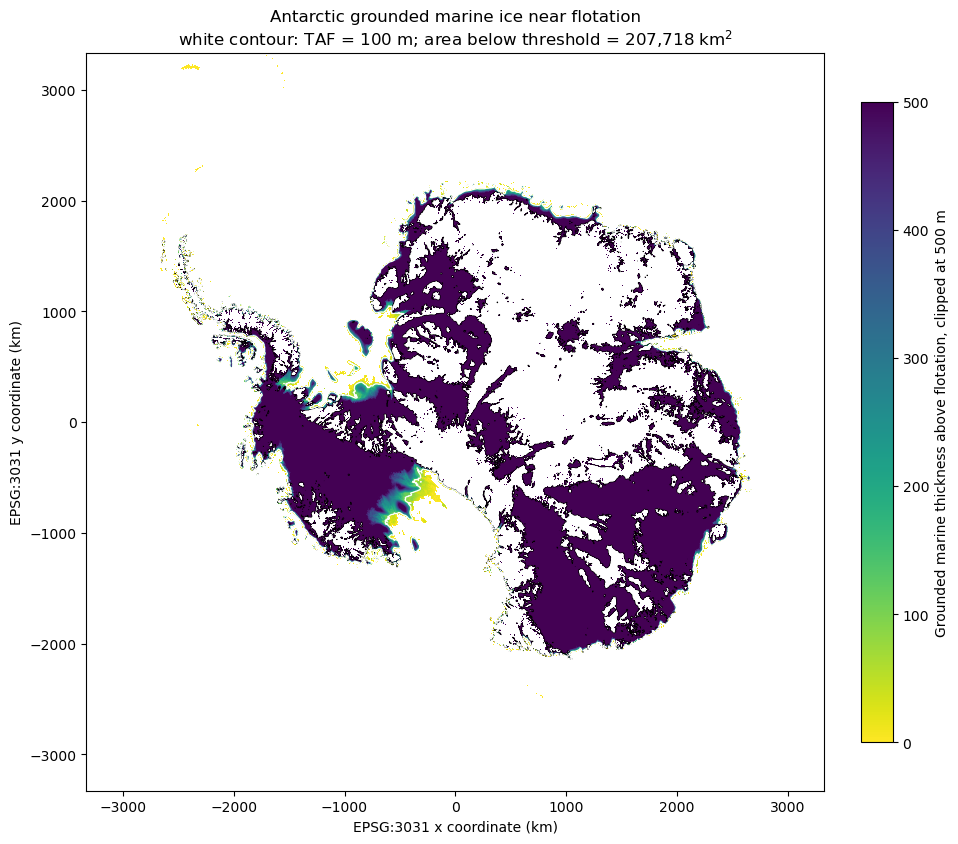

In [8]:
fig, ax = plot_taf_map(
    zarr_store,
    calc,
    plot_vmax_m=500,
    max_plot_pixels=1600,
    save_path="bedmachine_thickness_above_flotation.png",
)